In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('imdb_data.csv')
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [3]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

df['sentiment'] = encoder.fit_transform(df['sentiment'])
df['sentiment']

0        1
1        1
2        1
3        0
4        1
        ..
49995    1
49996    0
49997    0
49998    0
49999    0
Name: sentiment, Length: 50000, dtype: int64

In [4]:
X = df['review'].values
y = df['sentiment'].values

In [5]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [6]:
VOCAB_SIZE = 10000
MAX_LEN = 200

In [7]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')

tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [8]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

X_train_pad = pad_sequences(X_train_seq, maxlen = MAX_LEN, padding="post", truncating="post")
X_test_pad = pad_sequences(X_test_seq, maxlen = MAX_LEN, padding="post", truncating="post")

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, Flatten

model = Sequential()

model.add(Embedding(input_dim = VOCAB_SIZE, output_dim = 64, input_length = MAX_LEN))
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.summary()

C:\Users\DELL\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [11]:
history = model.fit(
    X_train_pad,
    y_train,
    epochs = 10,
    batch_size = 32,
    validation_split = 0.1,
    verbose = 1
)

Epoch 1/10
985/985 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.7919 - loss: 0.4227 - val_accuracy: 0.8640 - val_loss: 0.3169
Epoch 2/10
985/985 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9581 - loss: 0.1164 - val_accuracy: 0.8380 - val_loss: 0.4639
Epoch 3/10
985/985 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9953 - loss: 0.0157 - val_accuracy: 0.8491 - val_loss: 0.6284
Epoch 4/10
985/985 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9997 - loss: 0.0021 - val_accuracy: 0.8517 - val_loss: 0.7246
Epoch 5/10
985/985 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 1.0000 - loss: 2.9183e-04 - val_accuracy: 0.8549 - val_loss: 0.7813
Epoch 6/10
985/985 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 1.0000 - loss: 6.1586e-05 - val_accuracy: 0.8534 - val_loss: 0.8112
Epoch 7/10
985/985 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 1.0000 - loss: 2.8937e-05 - val_accuracy: 0.8534 - val_loss: 0.8389
Epoch 8/10
985/985 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 1.0000 - loss: 1.5435e-05 - 

In [12]:
loss, accuracy = model.evaluate(X_test_pad, y_test, verbose=1)
print("Accuracy: ", accuracy)
print("Loss: ", loss)

469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8082 - loss: 0.9893
Accuracy:  0.8082000017166138
Loss:  0.9893475770950317


In [13]:
y_pred_prob = model.predict(X_test_pad)
y_pred = (y_pred_prob > 0.5).astype(int)

469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


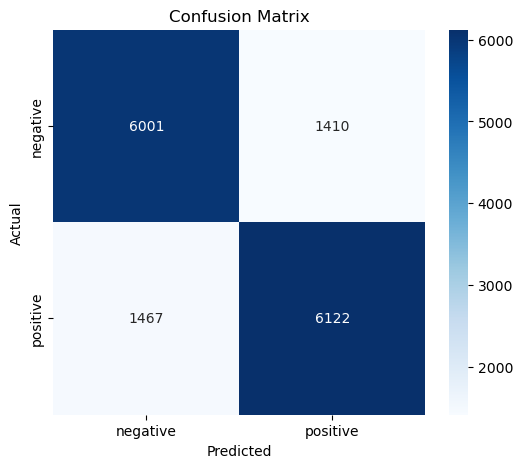

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['negative', 'positive'], yticklabels=['negative', 'positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [15]:
print('Classification Report: ')
print(classification_report(y_test, y_pred, target_names=['negative', 'positive']))

Classification Report: 
              precision    recall  f1-score   support

    negative       0.80      0.81      0.81      7411
    positive       0.81      0.81      0.81      7589

    accuracy                           0.81     15000
   macro avg       0.81      0.81      0.81     15000
weighted avg       0.81      0.81      0.81     15000

